In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np

from simulate.module import Module
from simulations import cycle

In [17]:
# Define the interpolants for the cell parameters
interpolants: dict = {
    "Open-circuit voltage / V": "lut",
    "R0 / Ohm": "spline",
    "R1 / Ohm": "spline",
    "R2 / Ohm": "spline",
    "R3 / Ohm": "spline",
    "Tau1 / s": "constant",
    "Tau2 / s": "constant",
    "Tau3 / s": "constant",
}
# Define the options for the interpolants
interpolants_options: dict = {
    "Open-circuit voltage / V": {"kind": "quadratic"},
    "R0 / Ohm": {"k": 1, "n": 5},
    "R1 / Ohm": {"k": 1, "n": 5},
    "R2 / Ohm": {"k": 1, "n": 5},
    "R3 / Ohm": {"k": 1, "n": 5},
    "Tau1 / s": None,
    "Tau2 / s": None,
}

# Partially arbitrary parameters for the module
module = Module(
    n_parallel=20,
    n_series=12,
    cell_parameters={
        "Std SOH / %": 2,
        "Std SOR / %": 7,
        "Nominal capacity / Ah": 5.0,
        "Initial SOC / %": 30,
    },
    number_of_rc_elements=3,
    bussbar_parameters={
        "Positive terminal relative width / 1": 10,
        "Negative terminal relative width / 1": 10,
        "Mean series resistance / Ohm": 1e-3,
        "Std series resistance / Ohm": 1e-4,
        "Mean parallel resistance / Ohm": 1e-4,
        "Std parallel resistance / Ohm": 1e-5,
    },
    interpolants=interpolants,
    interpolants_options=interpolants_options,
)

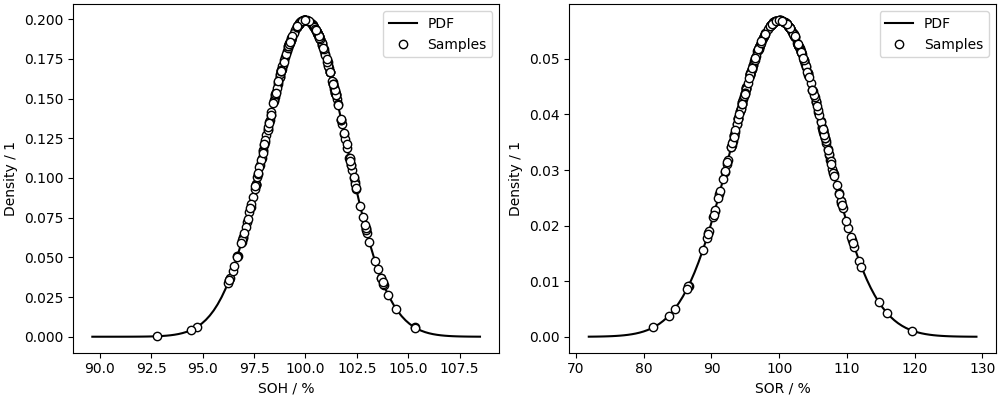

In [5]:
def pde(x, mu, sigma):
    return 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


# Simple visualization of the distributions of SOH and SOR in the cell grid
fig, axs = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

vals = [
    module.cellgrid.SOH.flatten() * 100,
    module.cellgrid.SOR.flatten() * 100,
]
mu = [
    module.cellgrid.parameters["Mean SOH / %"],
    module.cellgrid.parameters["Mean SOR / %"],
]
sigma = [
    module.cellgrid.parameters["Std SOH / %"],
    module.cellgrid.parameters["Std SOR / %"],
]
names = ["SOH / %", "SOR / %"]
for i, (x, m, s) in enumerate(zip(vals, mu, sigma)):
    rng = (x.max() - x.min()) * 0.25
    z = np.linspace(x.min() - rng, x.max() + rng, 100)
    axs[i].plot(z, pde(z, m, s), ls="-", color="k", label="PDF")
    axs[i].plot(
        x, pde(x, m, s), ls="none", marker="o", color="k", mfc="w", label="Samples"
    )
    axs[i].set_xlabel(names[i])
    axs[i].set_ylabel("Density / 1")
    axs[i].legend(loc="upper right")

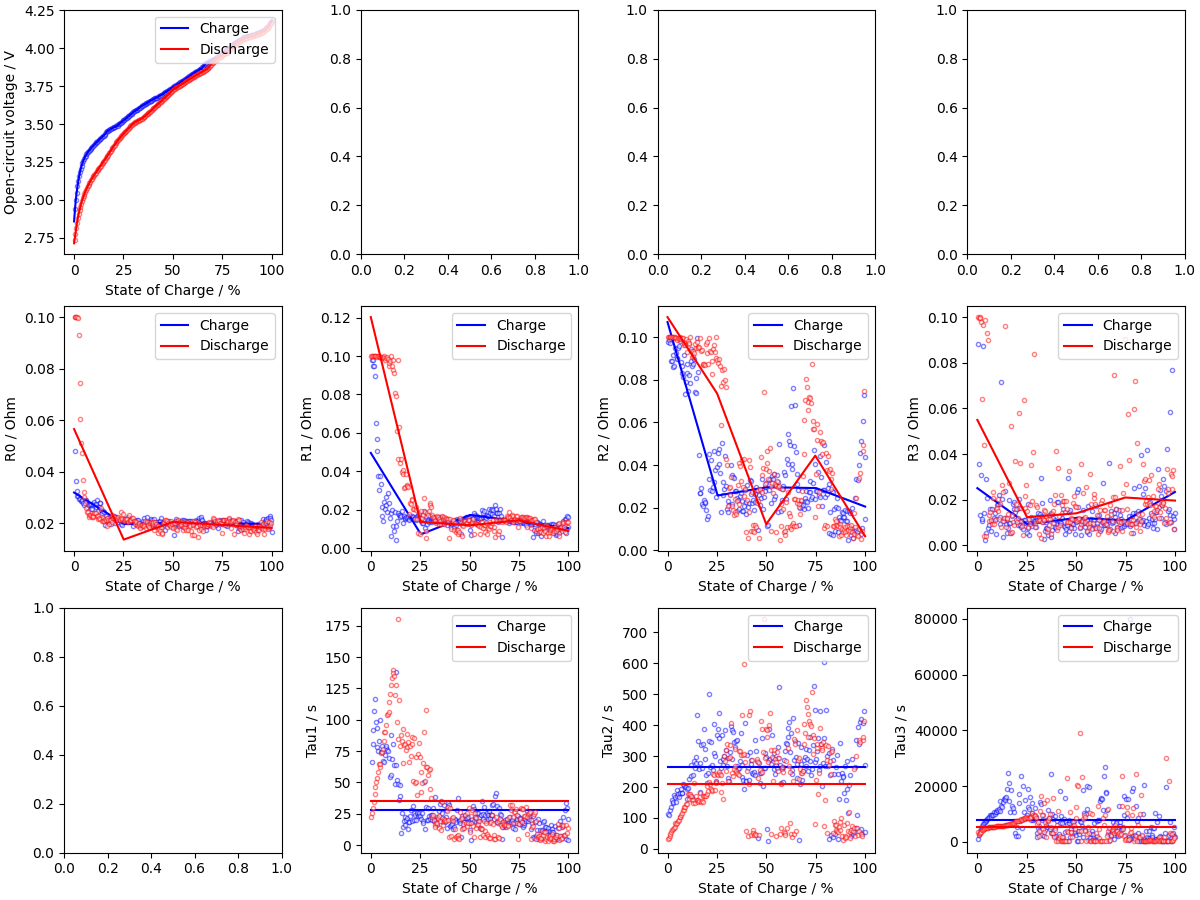

In [18]:
# Plot the interpolators for the cell parameters

keys = list(module.cellgrid.interpolators.keys())
colors = {"Charge": "blue", "Discharge": "red"}
keys.sort()

fig, axs = plt.subplots(3, 4, figsize=(12, 9), constrained_layout=True)
soc = np.linspace(0, 1, 1000)

for i, key in enumerate(keys):
    if key == "Open-circuit voltage / V":
        row, col = 0, 0
    elif key in ["R0 / Ohm", "R1 / Ohm", "R2 / Ohm", "R3 / Ohm"]:
        row = 1
        col = int(key[1])
    elif key in ["Tau1 / s", "Tau2 / s", "Tau3 / s"]:
        row = 2
        col = int(key[3])
    for mode, interp in module.cellgrid.interpolators[key].items():
        axs[row, col].plot(
            100 * interp.x,
            interp.y,
            ls="none",
            marker=".",
            color=colors[mode],
            mfc="w",
            alpha=0.5,
        )
        axs[row, col].plot(100 * soc, interp(soc), label=mode, color=colors[mode])
    axs[row, col].set_xlabel("State of Charge / %")
    axs[row, col].set_ylabel(key)
    axs[row, col].legend(loc="upper right")


In [23]:
# Simulate some simple cycles:
# CCharge
# Rest
# CCDischarge
# Rest

sim = cycle(
    module,
    dod=0.4,
    n_cycles=2,
    t_rest=600,
    c_charge=2,
    c_discharge=0.5,
    dt=1,
    newton_options={"sparse": True, "tol": 1e-6},
)

Integrating:   0%|          | 0/10199 [00:00<?, ?step/s]

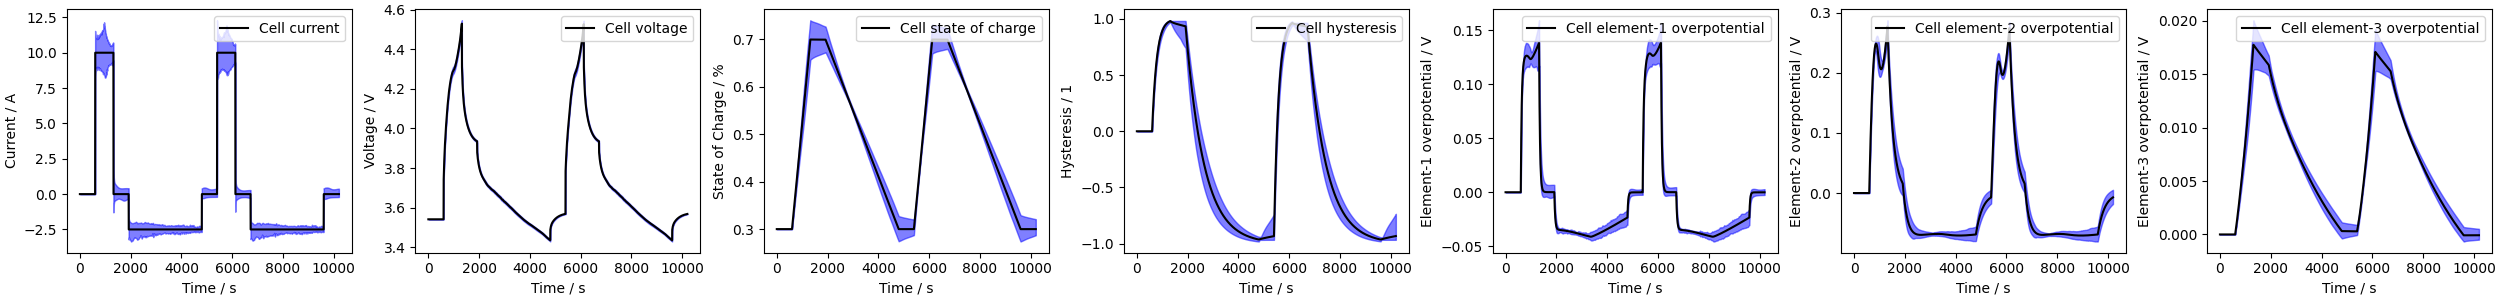

In [24]:
fig, axs = plt.subplots(
    1,
    4 + module.cellgrid.number_of_rc_elements,
    figsize=(25, 3),
    constrained_layout=True,
)
for i, name in enumerate(
    [
        "Current / A",
        "Voltage / V",
        "State of Charge / %",
        "Hysteresis / 1",
    ]
    + [
        f"Element-{j} overpotential / V"
        for j in range(1, module.cellgrid.number_of_rc_elements + 1)
    ]
):
    axs[i].set_ylabel(name)
    axs[i].set_xlabel("Time / s")

k = sim.t.shape[0]

axs[0].plot(
    sim.t,
    sim.cell_current.reshape((k, -1)).mean(axis=1),
    color="k",
    alpha=1,
    label="Cell current",
)
axs[0].fill_between(
    sim.t,
    sim.cell_current.reshape((k, -1)).max(axis=1),
    sim.cell_current.reshape((k, -1)).min(axis=1),
    color="b",
    alpha=0.5,
    label="_",
)

axs[1].plot(
    sim.t,
    sim.cell_voltage.reshape((k, -1)).mean(axis=1),
    color="k",
    alpha=1,
    label="Cell voltage",
)
axs[1].fill_between(
    sim.t,
    sim.cell_voltage.reshape((k, -1)).max(axis=1),
    sim.cell_voltage.reshape((k, -1)).min(axis=1),
    color="b",
    alpha=0.5,
    label="_",
)
for i, key in enumerate(
    [
        "State of Charge / 1",
        "Hysteresis / 1",
    ]
    + [
        f"Element-{j} overpotential / V"
        for j in range(1, module.cellgrid.number_of_rc_elements + 1)
    ],
    start=2,
):
    axs[i].plot(
        sim.t,
        sim.states[key].reshape((k, -1)).mean(axis=1),
        color="k",
        alpha=1,
        label="Cell " + key.split(" /")[0].lower(),
    )
    axs[i].fill_between(
        sim.t,
        sim.states[key].reshape((k, -1)).max(axis=1),
        sim.states[key].reshape((k, -1)).min(axis=1),
        color="b",
        alpha=0.5,
        label="_",
    )
for ax in axs:
    ax.legend(loc="upper right")

fig.savefig("figures/sim_cycle_cell.png", dpi=300)

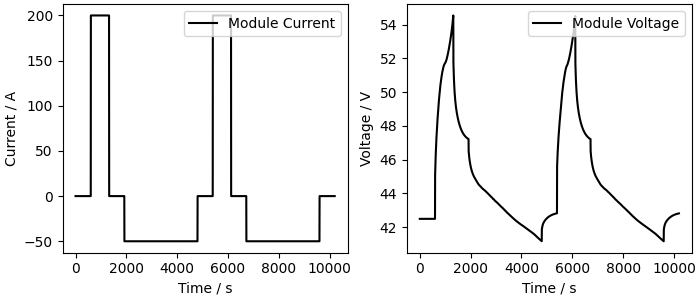

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)
axs[0].set_ylabel("Current / A")
axs[1].set_ylabel("Voltage / V")
for ax in axs:
    ax.set_xlabel("Time / s")

axs[0].plot(sim.t, sim.module_current, label="Module Current", color="k")
axs[1].plot(sim.t, sim.module_voltage, label="Module Voltage", color="k")
for ax in axs:
    ax.legend(loc="upper right")
fig.savefig("figures/sim_cycle_module.png", dpi=300)